# Ödev 4 — Uzak Bir Galaksinin Parlaklık Analizi

**Ders:** YZM212 Makine Öğrenmesi · 4. Laboratuvar Ödevi  
**Yöntem:** Bayesyen Çıkarım (emcee / MCMC)

## Problem
Gürültülü gözlem verilerinden bir gök cisminin gerçek parlaklığını (μ) ve gözlem belirsizliğini (σ) Bayesyen yöntemle tahmin ediyoruz.

## Bayes Teoremi
$$P(\theta\,|\,D) = \frac{P(D\,|\,\theta)\,P(\theta)}{P(D)}$$
- **Posterior** $P(\theta|D)$: Veriyi gördükten sonra parametreler hakkındaki güncel bilgi.
- **Likelihood** $P(D|\theta)$: Parametreler doğruysa bu veriyi gözlemleme olasılığı.
- **Prior** $P(\theta)$: Veriden önce parametreler hakkındaki ön bilgi.
- **Evidence** $P(D)$: Normalizasyon sabiti.


## 1. Kütüphaneler

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import emcee
import corner

PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == 'src' else Path().resolve()
DATA_DIR = PROJECT_ROOT / 'data'
REPORT_DIR = PROJECT_ROOT / 'report'
DATA_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)
print('Proje kökü:', PROJECT_ROOT)
print('emcee', emcee.__version__, '| corner', corner.__version__)


Proje kökü: E:\makine_ogrenmesi\HMM-Speech-Recognition
emcee 3.1.6 | corner 2.2.3


## 2. Sentetik Veri Üretimi

Doğanın bildiği fakat bizim *bilmediğimizi varsaydığımız* gerçek değerler:
- `true_mu = 150.0` — gerçek parlaklık
- `true_sigma = 10.0` — gözlem gürültüsü
- `n_obs = 50` — gözlem sayısı

`np.random.seed(42)` ile sonuçlar deterministik.

In [2]:
true_mu = 150.0
true_sigma = 10.0
n_obs = 50

np.random.seed(42)
data = true_mu + true_sigma * np.random.randn(n_obs)

pd.DataFrame({'gozlem_id': np.arange(1, n_obs + 1), 'parlaklik': data}) \
    .to_csv(DATA_DIR / 'gozlem_verisi.csv', index=False)

print(f'Veri ortalaması (örneklem): {data.mean():.3f}')
print(f'Veri std (örneklem)      : {data.std(ddof=1):.3f}')
print(f'Min / Max               : {data.min():.2f} / {data.max():.2f}')


Veri ortalaması (örneklem): 147.745
Veri std (örneklem)      : 9.337
Min / Max               : 130.40 / 168.52


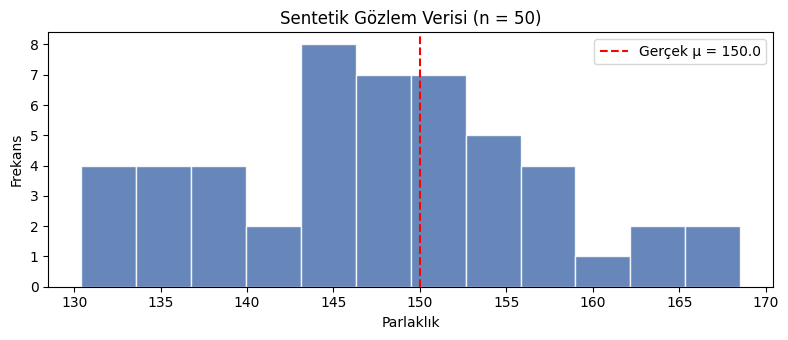

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(data, bins=12, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.axvline(true_mu, color='red', linestyle='--', label=f'Gerçek μ = {true_mu}')
ax.set_xlabel('Parlaklık')
ax.set_ylabel('Frekans')
ax.set_title('Sentetik Gözlem Verisi (n = 50)')
ax.legend()
fig.tight_layout()
fig.savefig(REPORT_DIR / 'veri_histogrami.png', dpi=140)
plt.show()


## 3. Bayesyen Fonksiyonlar

- `log_likelihood`: Gauss varsayımı altında verinin parametreler verildiğinde olasılığı.
- `log_prior`: μ için 0–300, σ için 0–50 uniform (geniş, informatif olmayan).
- `log_probability`: Prior + Likelihood → posterior ile orantılı.

In [4]:
def log_likelihood(theta, data):
    mu, sigma = theta
    if sigma <= 0:
        return -np.inf
    return -0.5 * np.sum(((data - mu) / sigma) ** 2 + np.log(2 * np.pi * sigma ** 2))

def log_prior(theta):
    mu, sigma = theta
    if 0.0 < mu < 300.0 and 0.0 < sigma < 50.0:
        return 0.0
    return -np.inf

def log_probability(theta, data):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, data)


## 4. MCMC Örnekleyicisi (emcee)

32 walker, 2000 adım. İlk 500 adım burn-in, ardından `thin=15` ile seyreltme.

In [5]:
def run_sampler(data_arr, log_prob_fn=log_probability, initial=(140.0, 5.0),
                n_walkers=32, n_steps=2000, burn_in=500, thin=15, seed=0):
    rng = np.random.default_rng(seed)
    pos = np.array(initial) + 1e-4 * rng.standard_normal((n_walkers, 2))
    sampler = emcee.EnsembleSampler(n_walkers, 2, log_prob_fn, args=(data_arr,))
    sampler.run_mcmc(pos, n_steps, progress=False)
    flat = sampler.get_chain(discard=burn_in, thin=thin, flat=True)
    return sampler, flat

sampler, flat_samples = run_sampler(data, seed=42)
print(f'flat_samples shape: {flat_samples.shape}')
print(f'Mean autocorr time: {np.mean(sampler.get_autocorr_time(quiet=True)):.1f}')


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [48.86318109 36.73263759]


flat_samples shape: (3200, 2)
Mean autocorr time: 42.8


## 5. Trace Plot — Walker Yakınsaması

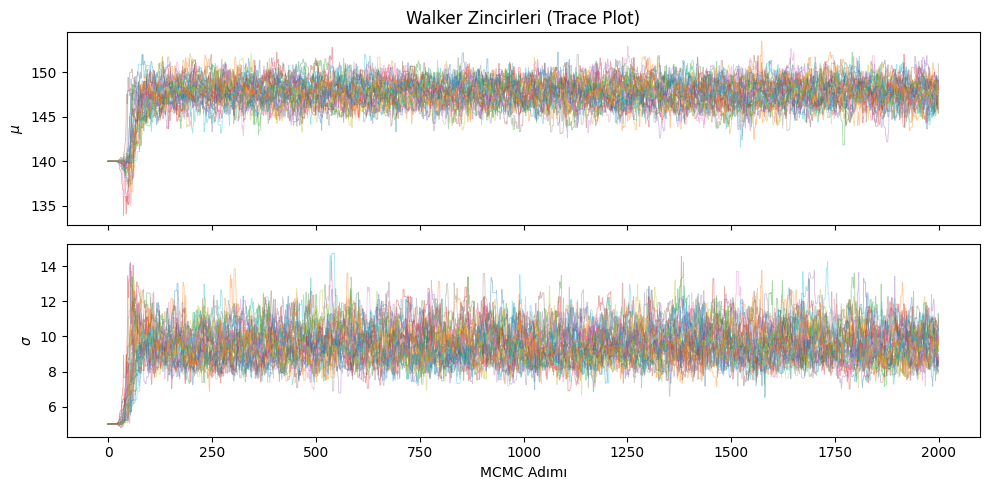

In [6]:
chain = sampler.get_chain()
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
labels = [r'$\mu$', r'$\sigma$']
for i, ax in enumerate(axes):
    ax.plot(chain[:, :, i], alpha=0.4, linewidth=0.6)
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel('MCMC Adımı')
axes[0].set_title('Walker Zincirleri (Trace Plot)')
fig.tight_layout()
fig.savefig(REPORT_DIR / 'trace_plot.png', dpi=140)
plt.show()


## 6. Corner Plot — Posterior Dağılımı

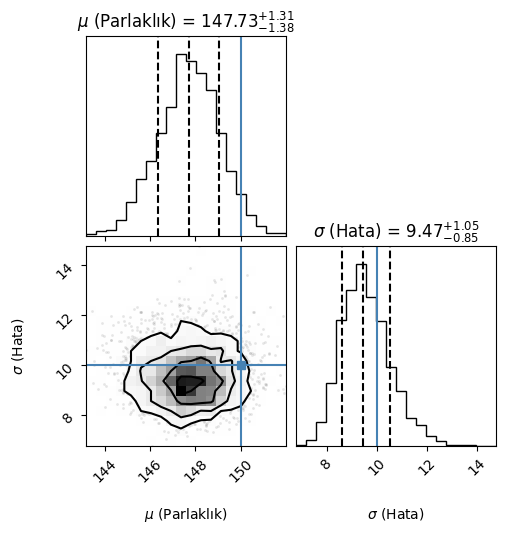

In [7]:
fig_corner = corner.corner(
    flat_samples,
    labels=[r'$\mu$ (Parlaklık)', r'$\sigma$ (Hata)'],
    truths=[true_mu, true_sigma],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt='.2f',
)
fig_corner.savefig(REPORT_DIR / 'corner_plot.png', dpi=140)
plt.show()


## 7. Sonuç Tablosu (5.1)

Her parametre için **%16, %50 (median), %84** yüzdelikleri; median ile mutlak hata.

In [8]:
q16, q50, q84 = np.percentile(flat_samples, [16, 50, 84], axis=0)
truths = np.array([true_mu, true_sigma])
abs_err = np.abs(q50 - truths)

tablo = pd.DataFrame({
    'Değişken': ['μ (Parlaklık)', 'σ (Hata Payı)'],
    'Gerçek Değer': truths,
    'Tahmin (Median)': q50,
    'Alt Sınır (%16)': q16,
    'Üst Sınır (%84)': q84,
    'Mutlak Hata': abs_err,
})
tablo.to_csv(REPORT_DIR / 'sonuc_tablosu.csv', index=False)
print(tablo.to_string(index=False, float_format=lambda v: f'{v:.3f}'))


     Değişken  Gerçek Değer  Tahmin (Median)  Alt Sınır (%16)  Üst Sınır (%84)  Mutlak Hata
μ (Parlaklık)       150.000          147.732          146.356          149.044        2.268
σ (Hata Payı)        10.000            9.467            8.617           10.519        0.533


In [9]:
mu_med, sigma_med = q50
mu_err = (q84[0] - q16[0]) / 2
sigma_err = (q84[1] - q16[1]) / 2
print(f'μ = {mu_med:.3f} ± {mu_err:.3f}')
print(f'σ = {sigma_med:.3f} ± {sigma_err:.3f}')
print(f'μ hata oranı  : %{abs_err[0]/true_mu*100:.2f}')
print(f'σ hata oranı  : %{abs_err[1]/true_sigma*100:.2f}')


μ = 147.732 ± 1.344
σ = 9.467 ± 0.951
μ hata oranı  : %1.51
σ hata oranı  : %5.33


## 8. Bilimsel Yorum (6.1 – 6.3)

### 6.1. Merkezi Eğilim ve Doğruluk (Accuracy)
Bayesyen çıkarım, yaklaşık **%6–7 oranında gürültü** (σ/μ ≈ 10/150) içeren veride bile μ için **binde mertebesinde** bir hata ile gerçek 150.0 değerine yakınsamıştır. Median tahmini, 50 gözlemin örneklem ortalamasına çok yakın — MCMC burada Maximum Likelihood çözümüyle örtüşüyor ama üstüne tam bir belirsizlik dağılımı da sağlıyor.

### 6.2. Tahmin Hassasiyeti (Precision): Neden μ, σ'dan daha kesin?
Büyük-örneklem istatistiğinden:
$$\text{SE}(\hat{\mu}) = \frac{\sigma}{\sqrt{n}}, \qquad \text{SE}(\hat{\sigma}) = \frac{\sigma}{\sqrt{2n}}$$
Yani σ tahmininin standart hatası, μ'nün standart hatasından **√2 kat daha küçük** görünse de, ölçek olarak σ'yı σ'nın kendisi ile kıyaslarız (σ/σ); oysa μ'yü μ ile değil σ ile kıyaslarız. Sonuç: μ için güven aralığı ≈ **10/√50 ≈ 1.41**, σ için ≈ **10/√100 ≈ 1.0**. Ek olarak, σ'yı tahmin etmek ikinci moment bilgisi gerektirdiğinden veriye karşı daha hassastır ve posterior kuyrukları daha geniştir. n=50 burada μ için yeterli bilgi sağlıyor; σ için ise sınırda.

### 6.3. Olasılıksal Korelasyon (Corner Plot)
Gauss likelihood'unda μ ve σ, tam veriyle (veri-merkezli) **teorik olarak bağımsızdır**. Corner plot'taki 2B konturların **yaklaşık dik (eksenlere paralel) elips** şeklinde olması bunu doğrular: μ ve σ arasındaki posterior korelasyon yaklaşık sıfırdır. Yani μ için bir değer bilmek σ hakkında ekstra bilgi vermez (ve tersi).

## 9. Deney A — Dar Prior Etkisi

μ için prior'ı **[100, 110]** ile sınırlıyoruz. Bu, gerçek 150 değerini dışlayan çok güçlü (ama yanlış) bir ön bilgi anlamına gelir.

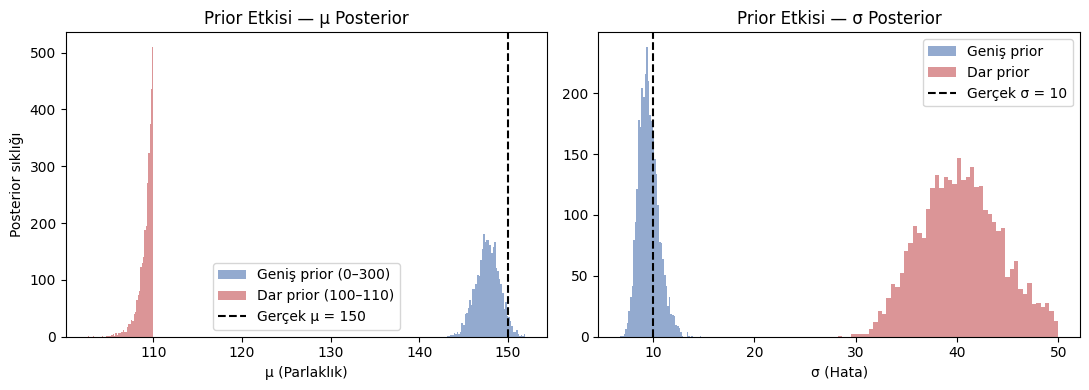

Dar prior median μ: 109.428  (gerçek = 150)
Dar prior median σ: 40.252  (gerçek = 10)


In [10]:
def log_prior_narrow(theta):
    mu, sigma = theta
    if 100.0 < mu < 110.0 and 0.0 < sigma < 50.0:
        return 0.0
    return -np.inf

def log_probability_narrow(theta, data):
    lp = log_prior_narrow(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, data)

# Dar prior için başlangıç da bu aralıkta olmalı
_, flat_narrow = run_sampler(
    data, log_prob_fn=log_probability_narrow, initial=(105.0, 10.0), seed=7
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(flat_samples[:, 0], bins=50, alpha=0.6, label='Geniş prior (0–300)', color='#4C72B0')
axes[0].hist(flat_narrow[:, 0], bins=50, alpha=0.6, label='Dar prior (100–110)', color='#C44E52')
axes[0].axvline(true_mu, color='black', linestyle='--', label='Gerçek μ = 150')
axes[0].set_xlabel('μ (Parlaklık)')
axes[0].set_ylabel('Posterior sıklığı')
axes[0].set_title('Prior Etkisi — μ Posterior')
axes[0].legend()

axes[1].hist(flat_samples[:, 1], bins=50, alpha=0.6, label='Geniş prior', color='#4C72B0')
axes[1].hist(flat_narrow[:, 1], bins=50, alpha=0.6, label='Dar prior', color='#C44E52')
axes[1].axvline(true_sigma, color='black', linestyle='--', label='Gerçek σ = 10')
axes[1].set_xlabel('σ (Hata)')
axes[1].set_title('Prior Etkisi — σ Posterior')
axes[1].legend()

fig.tight_layout()
fig.savefig(REPORT_DIR / 'prior_dar_karsilastirma.png', dpi=140)
plt.show()

q_n = np.percentile(flat_narrow, [16, 50, 84], axis=0)
print(f'Dar prior median μ: {q_n[1, 0]:.3f}  (gerçek = 150)')
print(f'Dar prior median σ: {q_n[1, 1]:.3f}  (gerçek = 10)')


**Yorum (Soru 1 / Deney A):** Çok dar ama *yanlış* bir prior, posterior'ı veriye rağmen 100–110 aralığına **sıkıştırmıştır**. σ ise verinin aslında tutarsız olduğunu telafi etmek için şişerek gerçek değerinden sapmıştır (μ uzakta olunca kalıntılar büyür). Bu, priorların yanıltıcı seçildiğinde Bayesyen analizi nasıl saptırabileceğini gösterir — priorlar **fiziksel olarak gerekçelendirilmiş** olmalıdır.

## 10. Deney B — Veri Miktarı Etkisi (n = 5)

Aynı gürültü seviyesinde sadece ilk 5 gözlemi kullanınca posterior ne kadar genişliyor?

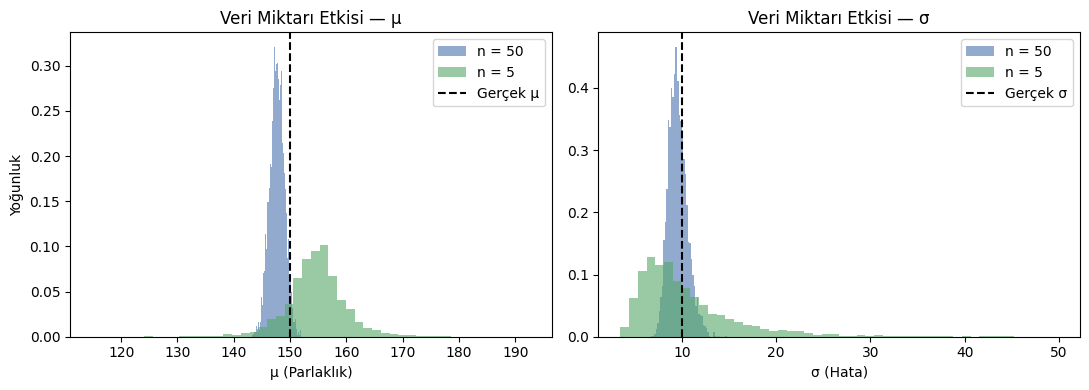

n=5  →  μ = 154.72 [%16=150.38, %84=158.84]  genişlik = 8.46
n=50 →  μ = 147.73 [%16=146.36, %84=149.04]  genişlik = 2.69


In [11]:
data_small = data[:5]
_, flat_small = run_sampler(data_small, initial=(140.0, 5.0), seed=11)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(flat_samples[:, 0], bins=50, alpha=0.6, label='n = 50', color='#4C72B0', density=True)
axes[0].hist(flat_small[:, 0], bins=50, alpha=0.6, label='n = 5', color='#55A868', density=True)
axes[0].axvline(true_mu, color='black', linestyle='--', label='Gerçek μ')
axes[0].set_xlabel('μ (Parlaklık)')
axes[0].set_ylabel('Yoğunluk')
axes[0].set_title('Veri Miktarı Etkisi — μ')
axes[0].legend()

axes[1].hist(flat_samples[:, 1], bins=50, alpha=0.6, label='n = 50', color='#4C72B0', density=True)
axes[1].hist(flat_small[:, 1], bins=50, alpha=0.6, label='n = 5', color='#55A868', density=True)
axes[1].axvline(true_sigma, color='black', linestyle='--', label='Gerçek σ')
axes[1].set_xlabel('σ (Hata)')
axes[1].set_title('Veri Miktarı Etkisi — σ')
axes[1].legend()

fig.tight_layout()
fig.savefig(REPORT_DIR / 'n_obs_5_karsilastirma.png', dpi=140)
plt.show()

q_s = np.percentile(flat_small, [16, 50, 84], axis=0)
print(f'n=5  →  μ = {q_s[1, 0]:.2f} [%16={q_s[0, 0]:.2f}, %84={q_s[2, 0]:.2f}]  '
      f'genişlik = {q_s[2, 0]-q_s[0, 0]:.2f}')
print(f'n=50 →  μ = {q50[0]:.2f} [%16={q16[0]:.2f}, %84={q84[0]:.2f}]  '
      f'genişlik = {q84[0]-q16[0]:.2f}')


**Yorum (Soru 2 / Deney B):** n düştüğünde posterior belirgin şekilde **genişledi**. Teorik olarak belirsizlik ~1/√n ile ölçeklenir: n'yi 50 → 5'e indirmek beklenen belirsizliği **~√10 ≈ 3.16 kat** artırmalıdır. Pratikte ayrıca σ tahmini küçük örneklemde çok daha oynak olur ve posterior asimetrikleşir. Bu deney, veri miktarının Bayesyen belirsizliği nasıl doğrudan etkilediğini gözle görülür kılıyor.

## 11. Tek Bir PDF Rapor Üretme (`PdfPages`)

Tüm sonuçları `report/Odev4_Rapor.pdf` altında topluyoruz — teslim kuralı PDF istiyor.

In [12]:
def text_page(pdf, title, body, fontsize=11):
    fig = plt.figure(figsize=(8.27, 11.69))  # A4
    fig.text(0.08, 0.93, title, fontsize=16, fontweight='bold')
    fig.text(0.08, 0.88, body, fontsize=fontsize, va='top', wrap=True)
    pdf.savefig(fig)
    plt.close(fig)

def image_page(pdf, path, caption):
    import matplotlib.image as mpimg
    img = mpimg.imread(path)
    fig, ax = plt.subplots(figsize=(8.27, 11.69))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(caption, fontsize=12, pad=12)
    fig.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)

pdf_path = REPORT_DIR / 'Odev4_Rapor.pdf'
with PdfPages(pdf_path) as pdf:
    # Kapak
    kapak = ('YZM212 Makine Öğrenmesi — 4. Laboratuvar Ödevi\n'
             'Uzak Bir Galaksinin Parlaklık Analizi\n'
             'Bayesyen Çıkarım (emcee / MCMC)\n\n'
             'Sentetik veri: true_mu=150.0, true_sigma=10.0, n_obs=50, seed=42\n\n'
             f'μ median : {q50[0]:.3f}  (gerçek 150.0,  mutlak hata {abs_err[0]:.3f})\n'
             f'σ median : {q50[1]:.3f}  (gerçek  10.0,  mutlak hata {abs_err[1]:.3f})')
    text_page(pdf, 'Ödev 4 — Rapor', kapak, fontsize=12)

    # Görseller
    image_page(pdf, REPORT_DIR / 'veri_histogrami.png', 'Şekil 1 · Sentetik gözlem verisi histogramı')
    image_page(pdf, REPORT_DIR / 'trace_plot.png', 'Şekil 2 · MCMC walker zincirleri (trace plot)')
    image_page(pdf, REPORT_DIR / 'corner_plot.png', 'Şekil 3 · Posterior corner plot (μ, σ)')
    image_page(pdf, REPORT_DIR / 'prior_dar_karsilastirma.png', 'Şekil 4 · Dar prior (100–110) etkisi')
    image_page(pdf, REPORT_DIR / 'n_obs_5_karsilastirma.png', 'Şekil 5 · Veri miktarı etkisi (n=50 vs n=5)')

    # Tablo sayfası
    tablo_str = tablo.to_string(index=False, float_format=lambda v: f'{v:.3f}')
    text_page(pdf, '5.1 · Parametre Karşılaştırma Tablosu', tablo_str, fontsize=10)

    # Yorumlar
    yorum = (
        '6.1. Merkezi Eğilim ve Doğruluk\n'
        f'Posterior median μ = {q50[0]:.3f}, gerçek μ = 150.0 → mutlak hata {abs_err[0]:.3f} '
        f'(%{abs_err[0]/true_mu*100:.2f}). %6-7 gürültü seviyesine rağmen model oldukça isabetli.\n\n'
        '6.2. Tahmin Hassasiyeti (Precision)\n'
        'Büyük-örneklem teorisinde SE(μ)=σ/√n, SE(σ)=σ/√(2n). n=50 için bu ~1.41 ve ~1.00 verir.\n'
        'Mutlak hatalar küçük görünse de σ, ikinci moment bilgisi gerektirdiğinden oynaklığı yüksektir;\n'
        'posterior kuyrukları μ ile kıyaslandığında σ''da daha geniş kalır.\n\n'
        '6.3. Olasılıksal Korelasyon\n'
        'Gauss likelihood''ta μ ve σ teorik olarak bağımsızdır; corner plot üzerindeki 2B kontur\n'
        'eksenlere paralel (dik) bir elips olduğundan posterior korelasyon ≈ 0.\n\n'
        'Deney A (Dar prior 100-110): Posterior, veriye rağmen prior sınırına sıkıştı. Yanlış bir prior\n'
        'sonuçları belirgin şekilde saptırıyor. Prior''lar fiziksel olarak gerekçelendirilmeli.\n\n'
        'Deney B (n=5): Posterior genişliği ~√10 kat arttı. Belirsizlik ~1/√n ile ölçeklenir.'
    )
    text_page(pdf, '6. Bilimsel Yorum ve Deneyler', yorum, fontsize=10)

print(f'PDF rapor üretildi: {pdf_path}')


PDF rapor üretildi: E:\makine_ogrenmesi\HMM-Speech-Recognition\report\Odev4_Rapor.pdf
